In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import pandas as pd
thermal=pd.read_excel('df.xlsx',header=0,encoding = 'unicode_escape')

# Data Preparation

In [3]:
# in case original data summary needed
org_df=thermal.copy()

In [4]:
thermal.columns

Index(['Data contributor', 'Year', 'Season', 'Climate', 'City', 'Country',
       'Building type', 'Cooling startegy_building level',
       'Heating strategy_building level', 'Age', 'Sex', 'Thermal sensation',
       'Thermal sensation acceptability', 'Thermal preference',
       'Air movement acceptability', 'Air movement preference',
       'Thermal comfort', 'Clo', 'Average Metabolic rate',
       'Air temperature (¡F)', 'Ta_h (¡F)', 'Globe temperature (¡F)',
       'Relative humidity (%)', 'Air velocity (m/s)', 'Air velocity (fpm)',
       'Subject«s height (cm)', 'Blind (curtain)', 'Fan', 'Window', 'Door',
       'Heater', 'Outdoor monthly air temperature (¡F)', 'PMV', 'PPD'],
      dtype='object')

In [5]:
thermal.dropna(subset=['PPD'], how='all', inplace=True)

In [6]:
thermal.isnull().sum()

Data contributor                            0
Year                                        0
Season                                      0
Climate                                     0
City                                        0
Country                                     0
Building type                               0
Cooling startegy_building level             0
Heating strategy_building level         40362
Age                                         0
Sex                                         0
Thermal sensation                         130
Thermal sensation acceptability         28089
Thermal preference                      10586
Air movement acceptability              59478
Air movement preference                 42301
Thermal comfort                         47034
Clo                                       216
Average Metabolic rate                    216
Air temperature (¡F)                        0
Ta_h (¡F)                               48958
Globe temperature (¡F)            

In [7]:
# generate a comparison table after categorizing str variables

test1 = thermal.copy()

cat_col_list = ['Data contributor','Season','Climate','City','Country',
                'Building type','Cooling startegy_building level','Sex']

for col in cat_col_list:
    test1[col] = pd.Categorical(test1[col])
    test1['code'+' '+col] = test1[col].cat.codes
    if col==cat_col_list[0]:
        index_dic=test1.loc[:,[col, 'code'+' '+col]].drop_duplicates()
        index_dic.columns=['original value','code value']
        index_dic['Column']=col
    else:
        temp=test1.loc[:,[col, 'code'+' '+col]].drop_duplicates()
        temp.columns=['original value','code value']
        temp['Column']=col
        index_dic=pd.concat([index_dic, temp])
index_dic.reset_index(inplace=True)
index_dic.drop(labels='index',axis=1, inplace=True)
index_dic.head()
index_dic.shape

,original value,code value,Column
0,Hyojin Kim,13,Data contributor
1,Indraganti Madhavi,15,Data contributor
2,Yufeng Zhang,29,Data contributor
3,Myla Mary Andamon,20,Data contributor
4,Max Deuble and Richard de Dear,19,Data contributor


(143, 3)

In [8]:
# all the analysis code should work on 'test' dataframe
test = thermal.copy()

In [9]:
# categorize str variables into int
# cat_col_list = ['Data contributor','Season','Climate','City','Country',
#                 'Building type','Cooling startegy_building level','Sex']
test.reset_index(inplace=True)
test.drop(labels='index',axis=1, inplace=True)
for col in cat_col_list:
    test[col]=test[col].astype('category').cat.codes

In [10]:
# # show the problem of 'Age' column
# test.groupby('Data contributor').Year.unique()
# test.groupby('Data contributor').Age.unique()

In [11]:
# fix the 'Age' column problem

test.sort_values("Data contributor",ascending=True,inplace=True)
test.reset_index(inplace=True)
for i in range(test.shape[0]):
    if i==0:
        born_year = test.loc[i,'Year'] - test.loc[i,'Age']
    elif ((test.loc[i,'Data contributor']!=test.loc[i-1,'Data contributor']) and 
          (test.loc[i,'Data contributor']==test.loc[i+1,'Data contributor'])):
        born_year = test.loc[i,'Year'] - test.loc[i,'Age']
    else:
        test.loc[i,'Age'] = test.loc[i,'Year'] - born_year 

In [12]:
# drop unuseful columns from 'test' and rearrange column sequence

column_sequence=['PPD', 'Data contributor', 'Year', 'Season', 'Climate', 'City', 
                 'Country', 'Building type', 'Age', 'Sex', 'Air temperature (¡F)',
                 'Cooling startegy_building level', 'PMV']
test = test.loc[:,column_sequence]
test = test[column_sequence]
test.head()
test.shape

,PPD,Data contributor,Year,Season,Climate,City,Country,Building type,Age,Sex,Air temperature (¡F),Cooling startegy_building level,PMV
0,21.0,0,2000,3,6,16,1,2,44,1,64.1,0,-0.9
1,7.0,0,2000,0,6,16,1,2,44,1,78.4,0,0.3
2,6.0,0,2000,0,6,16,1,2,44,1,77.5,0,0.2
3,5.0,0,2000,0,6,16,1,2,44,1,76.4,0,0.0
4,5.0,0,2000,0,6,16,1,2,44,1,77.2,0,0.1


(66734, 13)

In [13]:
# save each person's data to a dataframe

names = locals()

for dc in test['Data contributor'].unique():
    names['subset'+str(dc)] = test[test['Data contributor']==dc].reset_index()

# Summary of Dataset
org_df--original dataset

test1 --drop nans from PPD, both str and int for catigorical variables,
        but "Age" not fixed

test  --drop nans from PPD, int for catigorical variables, "Age" fixed

In [15]:
org_df[['PPD', 'Thermal sensation', 'Thermal sensation acceptability', 'Thermal preference']].isnull().sum()
# all dataset
# how many unique values for each column
for col in org_df.columns[1:10]:
    col, len(org_df[col].unique())

# how many nans for each column
org_df.groupby(['Data contributor'])['Year'].count()

# range of "PPD" and "Air T"
(org_df.PPD.min(), org_df.PPD.max())
(org_df['Air temperature (¡F)'].min(), org_df['Air temperature (¡F)'].max())

PPD                                35495
Thermal sensation                   3129
Thermal sensation acceptability    45139
Thermal preference                 22083
dtype: int64

('Year', 32)

('Season', 4)

('Climate', 19)

('City', 96)

...

('Heating strategy_building level', 2)

('Age', 29)

Data contributor
Anoop Honnekeri                        1408
Antonio Augusto Xavier                  279
Bouden                                 1651
Candido, Christhina Maria              2075
Chris Benton                            509
Chungyoon Chun                          574
Cornelia Moosmann                       427
David Rowe                              390
Despoina Teli                          2990
Djamila                                 990
Federico Tartarini                      509
Fergus Nicol                           4199
Fred Bauman                              85
Gail Brager                             111
Gail Schiller                          2349
Giovanna Donnini                        869
Guy Newsham                            1859
Hyojin Kim                               84
Iftikhar Raja                           877
Indraganti Madhavi                     6048
Jill Brown                              118
John Busch                             1168
Kazuyo Tsuzuki 

(5.0, 99.12)

(33.1, 145.8)

In [16]:
# summary of the original dataset

df=org_df.loc[:,column_sequence]
df.head()
df.shape
# each data contributor
str_var=[]
feature_list=['Air temperature (¡F)','PPD']
for p in df['Data contributor'].unique():
    sub_df=df[df['Data contributor']==p]
    for feature in feature_list:
        one_feature=sub_df[feature].describe().transpose().values
        if p=='Kwok Alison' and feature=='Air temperature (¡F)':
            num_var=one_feature
        else:
            num_var=np.append(num_var,one_feature)
    str_var.extend((p, sub_df.shape[0]))
    for col in df.columns[2:10]:
        str_var.append(len(sub_df[col].unique()))

num_var = num_var.reshape(len(df['Data contributor'].unique()),2*8)
num_var = pd.DataFrame(num_var)
data_df = num_var.iloc[:,[3,5,7,1,2,11,13,15,9,10]]
data_df.columns = ['Air_T_min', 'Air_T_medium', 'Air_T_max', 'Air_T_mean', 'Air_T_std',
                   'PPD_min', 'PPD_medium', 'PPD_max', 'PPD_mean', 'PPD_std']

col_list = ['Data contributor', 'Size', 'Year', 'Season', 'Climate',
            'City', 'Country', 'Building type', 'Age', 'Sex']
str_var_arr = np.reshape(str_var, (53,len(col_list)))
str_var_df = pd.DataFrame(str_var_arr,columns=col_list)

info_df = pd.concat([str_var_df, data_df],axis=1)
info_df.sort_values("Data contributor",ascending=True,inplace=True)
info_df.reset_index(inplace=True)
info_df.drop(labels='index', axis=1, inplace=True)
info_df.shape
info_df

,PPD,Data contributor,Year,Season,Climate,City,Country,Building type,Age,Sex,Air temperature (¡F),Cooling startegy_building level,PMV
0,NaN,Kwok Alison,2000,Summer,Humid subtropical,Tokyo,Japan,Classroom,15,Female,75.6,Air Conditioned,NaN
1,NaN,Kwok Alison,2000,Summer,Humid subtropical,Tokyo,Japan,Classroom,15,Female,75.6,Air Conditioned,NaN
2,NaN,Kwok Alison,2000,Summer,Humid subtropical,Tokyo,Japan,Classroom,15,Female,75.6,Air Conditioned,NaN
3,NaN,Kwok Alison,2000,Summer,Humid subtropical,Tokyo,Japan,Classroom,15,Female,75.6,Air Conditioned,NaN
4,NaN,Kwok Alison,2000,Summer,Humid subtropical,Tokyo,Japan,Classroom,15,Female,75.6,Air Conditioned,NaN


(102229, 13)

(53, 20)

,Data contributor,Size,Year,Season,Climate,City,Country,Building type,Age,Sex,Air_T_min,Air_T_medium,Air_T_max,Air_T_mean,Air_T_std,PPD_min,PPD_medium,PPD_max,PPD_mean,PPD_std
0,Anoop Honnekeri,1408,1,4,1,1,1,1,1,1,58.4,74.05,107.1,73.598082,5.352837,NaN,NaN,NaN,NaN,NaN
1,Antonio Augusto Xavier,279,1,4,3,3,1,2,1,1,62.0,74.00,83.2,73.464158,4.329687,5.00,6.000,50.00,10.107527,8.147643
2,Bouden,1651,4,2,4,5,1,2,1,1,59.0,73.90,102.6,73.914859,9.140111,5.00,23.000,99.00,34.011096,29.282038
3,"Candido, Christhina Maria",2075,1,2,1,1,1,1,1,1,75.3,79.60,91.2,81.259614,4.110005,5.00,14.000,99.00,23.777349,21.675581
4,Chris Benton,509,3,3,1,2,1,1,1,1,66.5,72.00,78.0,71.884086,1.462188,5.00,18.960,98.06,24.161886,18.782327
5,Chungyoon Chun,574,2,1,1,1,1,2,1,1,68.4,78.75,83.7,78.696038,3.537443,NaN,NaN,NaN,NaN,NaN
6,Cornelia Moosmann,427,1,1,1,1,1,1,1,1,69.1,75.90,113.5,76.666979,4.865203,5.00,12.000,99.00,21.774580,21.832779
7,David Rowe,390,2,4,1,1,1,1,1,1,62.4,73.60,81.7,73.542308,2.924760,5.00,9.145,99.12,14.290851,14.567424
8,Despoina Teli,2990,2,1,1,1,1,1,1,1,63.0,71.65,83.0,71.965351,3.388011,5.00,11.000,87.00,15.873579,13.859934
9,Djamila,990,2,4,2,7,1,2,1,1,74.1,86.90,95.5,86.738283,3.375849,NaN,NaN,NaN,NaN,NaN


In [17]:
# summary of the selected and fixed dataset

df1 = test1.loc[:,column_sequence]
df1.sort_values("Data contributor",ascending=True,inplace=True)
df1.reset_index(inplace=True)
for i in range(df1.shape[0]):
    if i==0:
        born_year = df1.loc[i,'Year'] - df1.loc[i,'Age']
    elif ((df1.loc[i,'Data contributor']!=df1.loc[i-1,'Data contributor']) and 
          (df1.loc[i,'Data contributor']==df1.loc[i+1,'Data contributor'])):
        born_year = df1.loc[i,'Year'] - df1.loc[i,'Age']
    else:
        df1.loc[i,'Age'] = df1.loc[i,'Year'] - born_year

str1_var=[]
feature_list=['Air temperature (¡F)','PPD']
for p in df1['Data contributor'].unique():
    sub1_df=df1[df1['Data contributor']==p]
    for feature in feature_list:
        one_feature=sub1_df[feature].describe().transpose().values
        if p=='Antonio Augusto Xavier ' and feature=='Air temperature (¡F)':
            num1_var=one_feature
        else:
            num1_var=np.append(num1_var,one_feature)
    str1_var.extend((p, sub1_df.shape[0]))
    for col in df1.columns[3:11]:
        str1_var.append(len(sub1_df[col].unique()))

num1_var = num1_var.reshape(len(df1['Data contributor'].unique()),2*8)
num1_var = pd.DataFrame(num1_var)
data1_df = num1_var.iloc[:,[3,5,7,1,2,11,13,15,9,10]]
data1_df.columns = ['Air_T_min', 'Air_T_medium', 'Air_T_max', 'Air_T_mean', 'Air_T_std',
                    'PPD_min', 'PPD_medium', 'PPD_max', 'PPD_mean', 'PPD_std']

col_list = ['Data contributor', 'Size', 'Year', 'Season', 'Climate',
            'City', 'Country', 'Building type', 'Age', 'Sex']
str1_var_arr = np.reshape(str1_var, (30,len(col_list)))
str1_var_df = pd.DataFrame(str1_var_arr,columns=col_list)

info1_df = pd.concat([str1_var_df, data1_df],axis=1)
info1_df.head(10)
info1_df.shape

,Data contributor,Size,Year,Season,Climate,City,Country,Building type,Age,Sex,Air_T_min,Air_T_medium,Air_T_max,Air_T_mean,Air_T_std,PPD_min,PPD_medium,PPD_max,PPD_mean,PPD_std
0,Antonio Augusto Xavier,279,1,4,3,3,1,2,1,1,62.0,74.00,83.2,73.464158,4.329687,5.0,6.000,50.00,10.107527,8.147643
1,Bouden,1442,3,2,4,5,1,2,3,1,59.0,73.90,102.6,73.852566,9.088198,5.0,23.000,99.00,34.011096,29.282038
2,"Candido, Christhina Maria",2075,1,2,1,1,1,1,1,1,75.3,79.60,91.2,81.259614,4.110005,5.0,14.000,99.00,23.777349,21.675581
3,Chris Benton,509,3,3,1,2,1,1,3,1,66.5,72.00,78.0,71.884086,1.462188,5.0,18.960,98.06,24.161886,18.782327
4,Cornelia Moosmann,417,1,1,1,1,1,1,1,1,69.1,75.90,113.5,76.650120,4.898637,5.0,12.000,99.00,21.774580,21.832779
5,David Rowe,388,2,4,1,1,1,1,2,1,62.4,73.60,81.7,73.530670,2.925238,5.0,9.145,99.12,14.290851,14.567424
6,Despoina Teli,2990,2,1,1,1,1,1,2,1,63.0,71.65,83.0,71.965351,3.388011,5.0,11.000,87.00,15.873579,13.859934
7,Federico Tartarini,509,2,4,2,2,1,1,2,1,61.3,71.70,93.6,73.042240,4.741138,5.0,14.000,99.00,22.650295,21.013857
8,Fergus Nicol,4198,2,2,1,5,1,1,2,1,43.2,78.80,108.5,76.376608,12.632792,5.0,43.310,99.12,48.542847,34.361418
9,Fred Bauman,85,1,1,1,1,1,1,1,1,71.8,73.40,75.3,73.660000,0.779377,5.0,9.310,38.63,11.811059,7.480118


(30, 20)

# Group and Environment bin Generation

In [18]:
import random

person_df = test.iloc[:,[1,2,8,9]]
person_df['birth'] = test.iloc[:,2] - test.iloc[:,8]
person_df.drop(columns=['Year','Age'], inplace=True)
person_df.drop_duplicates(inplace=True)
#person_df.head(2)

room_var = ['Year', 'Season', 'Climate', 'City','Country', 'Building type']
room_df = test.loc[:, room_var]
room_df.drop_duplicates(inplace=True)
#room_df.head(2)

p_list = test['Data contributor'].unique()
group = random.sample(set(p_list), k=random.randint(1,len(p_list)))

i = random.randint(0,242)
room_bin = room_df.iloc[i,:].values.reshape(6,).tolist()

print(group)
room_bin

[23, 11, 4, 12, 5, 14, 20, 29, 24, 2, 8, 25, 7, 13, 1, 18, 15, 0, 3, 21]


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/opt/anaconda3/lib/python3.7/site-packages/pandas/core/frame.py:4102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

[1999, 1, 15, 45, 11, 3]

# "For" Loop Optimization

## build PPD Decision Trees

In [19]:
# use each person's date to train their own PPD Trees
from sklearn import tree
for dc in test['Data contributor'].unique():
    names['PPD_'+str(dc)] = tree.DecisionTreeRegressor()
    names['PPD_'+str(dc)] = names['PPD_'+str(dc)].fit(names['subset'+str(dc)].iloc[:,2:12],
                                                      names['subset'+str(dc)].PPD)

## build Air_T Decision Trees

In [20]:
# use each person's date to train their own Temperature Trees
from sklearn import tree
for dc in test['Data contributor'].unique():
    names['Air_T_'+str(dc)] = tree.DecisionTreeRegressor()
    names['Air_T_'+str(dc)] = names['Air_T_'+str(dc)].fit(names['subset'+str(dc)].iloc[:,1:11],
                                                          names['subset'+str(dc)]['Air temperature (¡F)'])

## using both sum(PPDi) and sum(exp(PPD)*(Tio-To)^2) to find To

In [21]:
import math

sum_PPD_1 = 100*len(group)
for T in np.arange(60, 85.1, 0.1):
    temp_1 = 0
    temp_2 = 0
    for person in group:
        age = (room_bin[0]-person_df[person_df['Data contributor']==person].birth.values).tolist()
        gender = person_df[person_df['Data contributor']==person].Sex.values.tolist()
        Denviron_bin = [person] + room_bin.copy() + age + gender + [T]
        ppd = names['PPD_'+str(person)].predict([Denviron_bin])[0]
        temp_1 += ppd
        Tenviron_bin = [0, person] + room_bin.copy() + age + gender
        t = names['Air_T_'+str(person)].predict([Tenviron_bin])[0]
        temp_2 += math.exp(ppd)*np.square(t-T)        
    if sum_PPD_1 > temp_1:
        To_1 = T
        sum_PPD_1 = temp_1
    if T==60:
        To_2 = T
        ind = temp_2
        sum_PPD_2 = temp_1
    else:
        if ind > temp_2:
            To_2 = T
            ind = temp_2
            sum_PPD_2 = temp_1

print(group)
room_bin
To_1
sum_PPD_1/len(group)
ind
To_2
sum_PPD_2/len(group)

[23, 11, 4, 12, 5, 14, 20, 29, 24, 2, 8, 25, 7, 13, 1, 18, 15, 0, 3, 21]


[1999, 1, 15, 45, 11, 3]

80.10000000000028

12.05663888888889

189944198111868.88

73.9000000000002

13.998683333333336

## histograms of PPDi for two obj functions

(0, 38.92)

Text(0.5, 1.0, 'Dissatisfaction Level Distribution')

Text(0, 0.5, 'Dissatisfaction Level')

Text(0.5, 0, 'Person Index')

<Figure size 360x288 with 0 Axes>

Text(0.5, 1.0, 'Sensitivity Comparison')

Text(0, 0.5, 'Difference of Dissatisfaction')

Text(0.5, 0, 'Person Index')

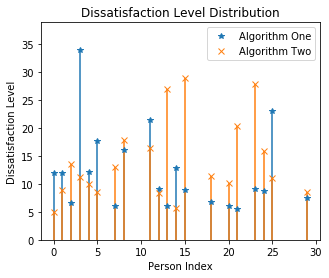

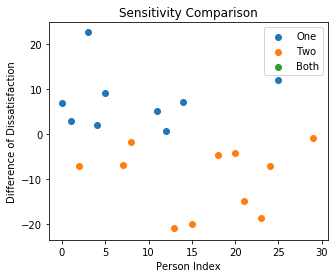

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

PPD_list_1 = []
PPD_list_2 = []

group_sort = sorted(group)

for person in group_sort:
    age = (room_bin[0]-person_df[person_df['Data contributor']==person].birth.values).tolist()
    gender = person_df[person_df['Data contributor']==person].Sex.values.tolist()
    Denviron_bin_1 = [person] + room_bin.copy() + age + gender + [To_1]
    Denviron_bin_2 = [person] + room_bin.copy() + age + gender + [To_2]
    ppd1 = names['PPD_'+str(person)].predict([Denviron_bin_1])[0]
    ppd2 = names['PPD_'+str(person)].predict([Denviron_bin_2])[0]
    PPD_list_1.append(ppd1)
    PPD_list_2.append(ppd2)

chart = {"person" : group_sort,
         "obj1" : PPD_list_1,
         "obj2" : PPD_list_2,
         "dif" : np.array(PPD_list_1)-np.array(PPD_list_2),
         "prefer" : np.array(PPD_list_1)-np.array(PPD_list_2)
} 
chart_df = pd.DataFrame(chart)
for i in range(chart_df.shape[0]):
    if chart_df.iloc[i,4] == 0:
        chart_df.iloc[i,4] = "Both"
    elif chart_df.iloc[i,4] > 0:
        chart_df.iloc[i,4] = "One"
    else:
        chart_df.iloc[i,4] = "Two"

fig, ax = plt.subplots(figsize=(5, 4))
ax.vlines(group_sort, ymin=0, ymax=PPD_list_1,color='C0')
ax.plot(group_sort, PPD_list_1, "*", color='C0')
ax.vlines(group_sort, ymin=0, ymax=PPD_list_2, color='C1')
ax.plot(group_sort, PPD_list_2, "x", color='C1')
ax.set_ylim(0, np.max(PPD_list_1+PPD_list_2)+5)
ax.legend(['Algorithm One','Algorithm Two'], loc='upper right')
ax.set_title('Dissatisfaction Level Distribution')
ax.set_ylabel('Dissatisfaction Level')
ax.set_xlabel('Person Index')
plt.figure(figsize=(5,4))
plt.title('Sensitivity Comparison')
plt.scatter(chart_df[chart_df.prefer=='One'].person, chart_df[chart_df.prefer=='One'].dif)
plt.scatter(chart_df[chart_df.prefer=='Two'].person, chart_df[chart_df.prefer=='Two'].dif)
plt.scatter(chart_df[chart_df.prefer=='Both'].person, chart_df[chart_df.prefer=='Both'].dif)
plt.legend(['One','Two','Both'], loc='upper right')
plt.ylabel('Difference of Dissatisfaction')
plt.xlabel('Person Index')

# CVX Library Optimization

In [69]:
!pip install --user cvxopt

In [23]:
# build PPD-tree to get PPDs for each person's simulation dataset

from sklearn import tree
PPD_all = tree.DecisionTreeRegressor()
PPD_all = PPD_all.fit(test.iloc[:,1:11], test.PPD)

In [24]:
Dsimu0=pd.read_excel('gp-data-0.xlsx',header=0,encoding = 'unicode_escape')
Dsimu0.Sex=int(person_df[person_df['Data contributor']==0].Sex)
Dsimu0.PPD = PPD_all.predict(Dsimu0.iloc[:,1:])

In [25]:
for i in range(1,30):
    names['Dsimu'+str(i)] = Dsimu0.copy()
    names['Dsimu'+str(i)].Sex = int(person_df[person_df['Data contributor']==i].Sex)
    names['Dsimu'+str(i)].Age = names['Dsimu'+str(i)].Year - int(person_df[person_df['Data contributor']==i].birth)
    names['Dsimu'+str(i)].PPD = PPD_all.predict(names['Dsimu'+str(i)].iloc[:,1:])

## get PPD = f(Air_T) function for each person

<Figure size 360x11880 with 0 Axes>

Text(0.5, 1.0, 'Person 0 Room T & Unhappiness Level')

Text(0, 0.5, 'Unhappiness Level')

Text(0.5, 0, 'Room Temperature')

Text(0.5, 1.0, 'Person 1 Room T & Unhappiness Level')

...

Text(0, 0.5, 'Unhappiness Level')

Text(0.5, 0, 'Room Temperature')

Text(0.5, 1.0, 'Person 29 Room T & Unhappiness Level')

Text(0, 0.5, 'Unhappiness Level')

Text(0.5, 0, 'Room Temperature')

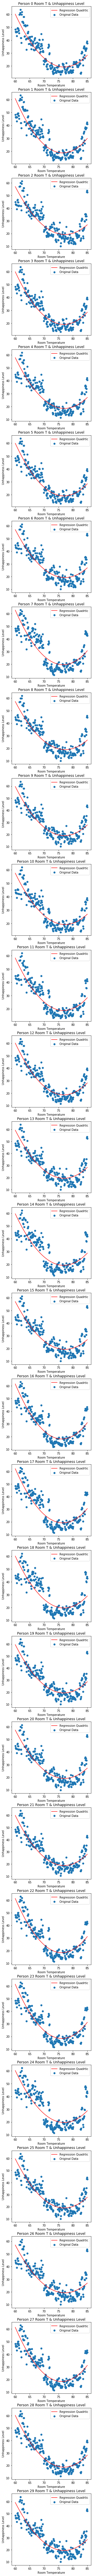

In [26]:
# plot Air_T vs PPD 
# build the quadratic model for each person
# plot the quadratic

from sklearn.linear_model import LinearRegression

T_arr = np.arange(60, 85.1, 0.1)
x1 = T_arr[:, np.newaxis]
x2 = x1**2
X = np.concatenate((x2, x1),axis=1)

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(5,165))
for i in range(30):
    plt.subplot(30,1,i+1)
    y = names['Dsimu'+str(i)].groupby(['Air temperature (¡F)']).PPD.mean()
    plt.scatter(T_arr, y)
    plt.title('Person '+str(i)+' Room T & Unhappiness Level')
    plt.ylabel('Unhappiness Level')
    plt.xlabel('Room Temperature')
    names['F_PPD_'+str(i)] = LinearRegression(normalize=True).fit(X, y)
    plt.plot(T_arr, names['F_PPD_'+str(i)].predict(X),color='r')
    plt.legend(['Regression Quadrtic', 'Original Data'],loc='upper right')

In [28]:
from cvxopt  import solvers, matrix

a0 = 0
a1 = 0

for person in group:
    a0 += names['F_PPD_'+str(person)].coef_[0]
    a1 += names['F_PPD_'+str(person)].coef_[1]

P = matrix([2*a0])
q = matrix([a1])
G = matrix([-1.0, 1.0])
h = matrix([-60.0, 85.0])

sol = solvers.qp(P,q,G,h)
print(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -1.6724e+04 -1.6809e+04  8e+01  0e+00  0e+00
 1: -1.6727e+04 -1.6730e+04  2e+00  0e+00  4e-17
 2: -1.6727e+04 -1.6727e+04  2e-02  0e+00  1e-16
 3: -1.6727e+04 -1.6727e+04  2e-04  0e+00  3e-17
Optimal solution found.
[ 7.69e+01]



19.300697793021175

(0, 24.90554048438821)

Text(0.5, 1.0, 'Dissatisfaction Level Distribution')

Text(0, 0.5, 'Dissatisfaction Level')

Text(0.5, 0, 'Person Index')

(0, 34.0)

Text(0.5, 1.0, 'Two Method Comparison')

Text(0, 0.5, 'Dissatisfaction Level')

Text(0.5, 0, 'Person Index')

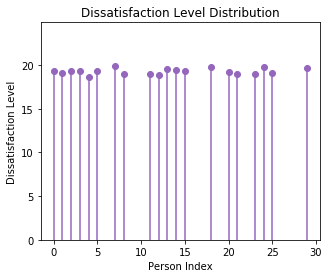

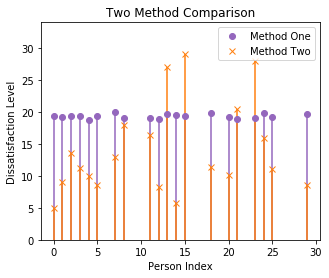

In [29]:
# average dissatisfaction level
# two model comparison

PPD_list = []
# group_sort = sorted(group)

for person in group_sort:
    ppd = names['F_PPD_'+str(person)].predict([[78.1**2,78.1]])[0]
    PPD_list.append(ppd)
    
np.mean(PPD_list)

fig, ax = plt.subplots(figsize=(5, 4))
ax.vlines(group_sort, ymin=0, ymax=PPD_list,color='C4')
ax.plot(group_sort, PPD_list, "o", color='C4')
ax.set_ylim(0, np.max(PPD_list)+5)
ax.set_title('Dissatisfaction Level Distribution')
ax.set_ylabel('Dissatisfaction Level')
ax.set_xlabel('Person Index')

fig, ax = plt.subplots(figsize=(5, 4))
ax.vlines(group_sort, ymin=0, ymax=PPD_list,color='C4')
ax.plot(group_sort, PPD_list, "o", color='C4')
ax.vlines(group_sort, ymin=0, ymax=PPD_list_2, color='C1')
ax.plot(group_sort, PPD_list_2, "x", color='C1')
ax.set_ylim(0, np.max(PPD_list+PPD_list_2)+5)
ax.legend(['Method One','Method Two'], loc='upper right')
ax.set_title('Two Method Comparison')
ax.set_ylabel('Dissatisfaction Level')
ax.set_xlabel('Person Index')